# Student Performance Analysis & Prediction

**Dataset:** `StudentPerformanceFactors.csv` — 6,607 students with study habits, attendance, family/school context, and final `Exam_Score`.

**Goal:** Explore the factors behind exam performance, then build a Linear Regression model to predict `Exam_Score`, first from core study-related features (study hours, attendance, previous scores), then from the full feature set to see how much additional context improves prediction.

**Tech stack:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer




## 1. Load the Dataset

In [5]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print("Shape: ",df.shape)
df.head()


Shape:  (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [7]:
df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 2. Data Cleaning

A quick check shows a few missing values in `Teacher_Quality`, `Parental_Education_Level`, and `Distance_from_Home`, and one clear outlier: a single `Exam_Score` of 101 on a 0-100 scale. We handle both before moving on.


In [11]:
print("Missing values per column:")

print(df.isnull().sum()[df.isnull().sum() > 0] )

print("\nRows with Exam_Score > 100:", (df["Exam_Score"] > 100).sum())


Missing values per column:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Rows with Exam_Score > 100: 1


In [17]:
# Remove rows where Exam_Score is greater than 100
df = df[df["Exam_Score"] <= 100]

# Fill missing values with the most common value
df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0], inplace=True)
df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0], inplace=True)
df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0], inplace=True)

# Check missing values and dataset size
print("Missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)

Missing values: 0
Shape: (6606, 20)


C:\Users\Sahil more\AppData\Local\Temp\ipykernel_14720\4157986544.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0], inplace=True)
C:\Users\Sahil more\AppData\Local\Temp\ipykernel_14720\4157986544.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame

## 3. Exploratory Data Analysis (EDA)

We'll look at:
- Overall distribution of exam scores
- The relationship between attendance and exam score
- Gender-wise performance gaps
- How study hours relate to performance
- The effect of contextual factors (parental involvement, motivation, peer influence)
- Feature correlations


### 3.1 Distribution of Exam Scores

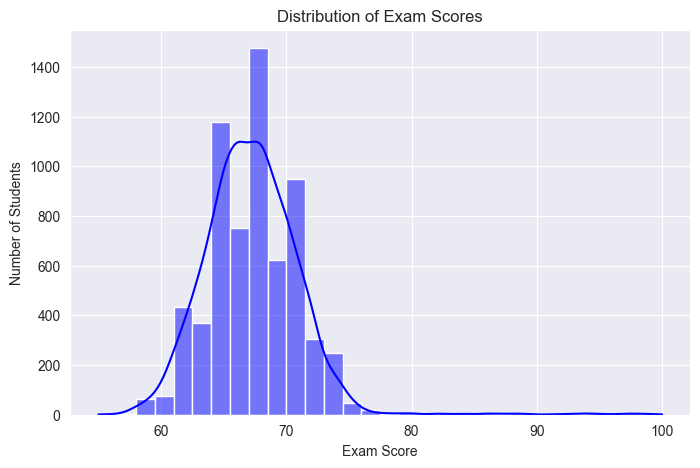

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Exam_Score"], bins=30, kde=True, color="blue")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()


### 3.2 Attendance vs Exam Score

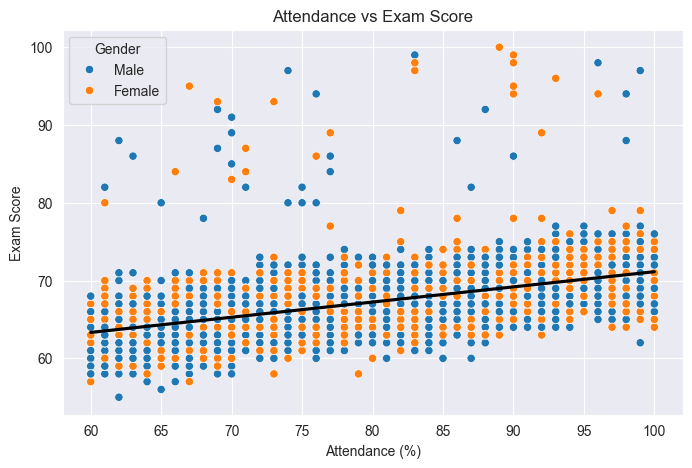

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Attendance", y="Exam_Score", hue="Gender")
ax = sns.regplot(data=df, x="Attendance", y="Exam_Score",scatter=False, color="black")
ax.lines[0].set_linestyle("--")
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

Higher attendance is associated with higher exam scores on average, though there's noticeable spread — attendance alone doesn't fully determine performance.

### 3.3 Gender-wise Performance Gap

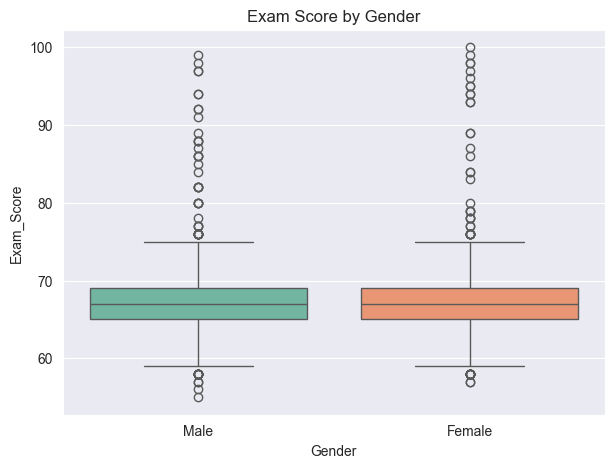

Mean:
Gender
Female    67.232808
Male      67.228894
Name: Exam_Score, dtype: float64

Median:
Gender
Female    67.0
Male      67.0
Name: Exam_Score, dtype: float64

Standard Deviation:
Gender
Female    4.004506
Male      3.766360
Name: Exam_Score, dtype: float64

Count:
Gender
Female    2792
Male      3814
Name: Exam_Score, dtype: int64


In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Gender", y="Exam_Score", hue="Gender", palette="Set2", legend=False)
plt.title("Exam Score by Gender")
plt.show()

print("Mean:")
print(df.groupby("Gender")["Exam_Score"].mean())

print("\nMedian:")
print(df.groupby("Gender")["Exam_Score"].median())

print("\nStandard Deviation:")
print(df.groupby("Gender")["Exam_Score"].std())

print("\nCount:")
print(df.groupby("Gender")["Exam_Score"].count())

### 3.4 Study Hours vs Exam Score

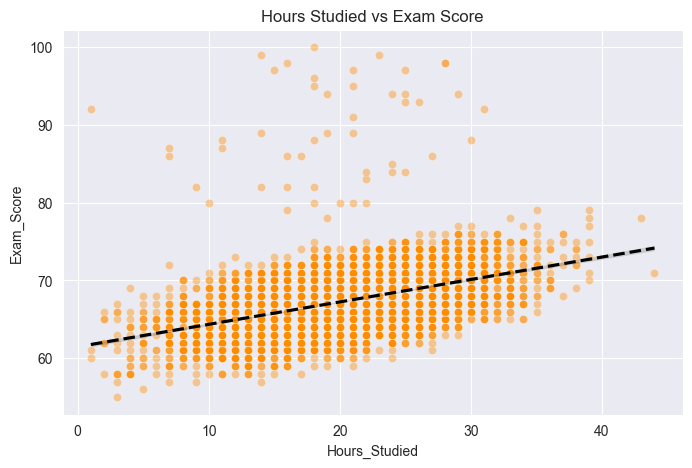

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score", alpha=0.4, color="darkorange")
ax = sns.regplot(data=df, x="Hours_Studied", y="Exam_Score",scatter=False, color="black")
ax.lines[0].set_linestyle("--")
plt.title("Hours Studied vs Exam Score")
plt.show()

### 3.5 Contextual Factors: Parental Involvement, Motivation, Peer Influence

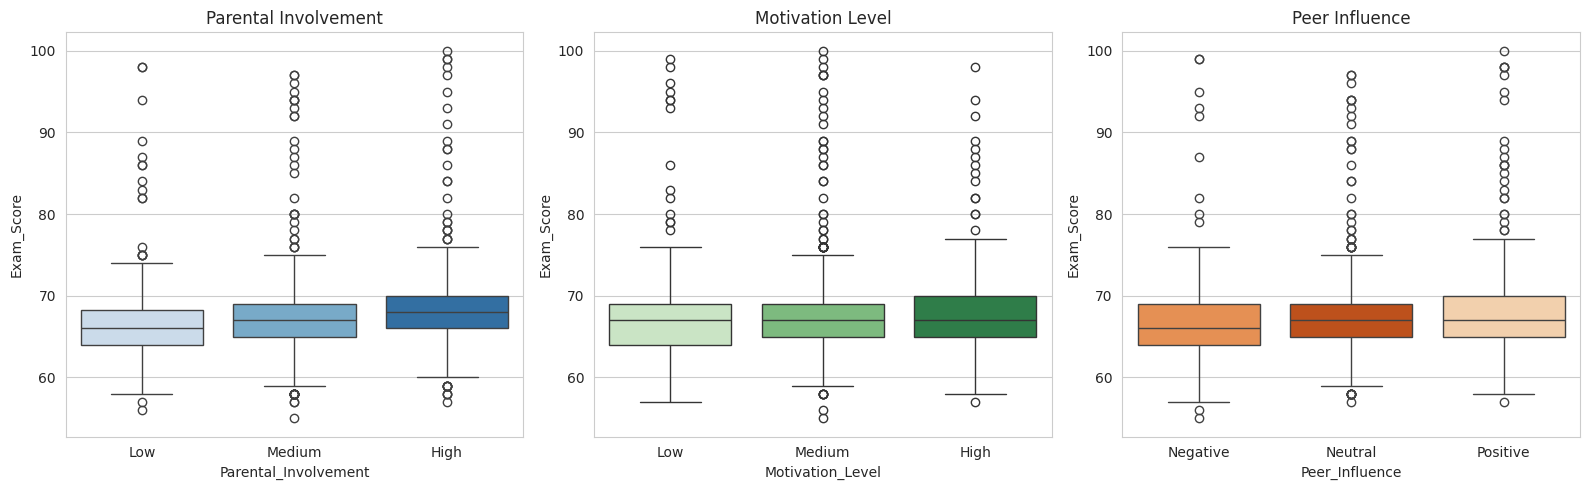

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Parental_Involvement", y="Exam_Score",
            order=["Low", "Medium", "High"], ax=axes[0], hue="Parental_Involvement",
            palette="Blues", legend=False)
axes[0].set_title("Parental Involvement")

sns.boxplot(data=df, x="Motivation_Level", y="Exam_Score",
            order=["Low", "Medium", "High"], ax=axes[1], hue="Motivation_Level",
            palette="Greens", legend=False)
axes[1].set_title("Motivation Level")

sns.boxplot(data=df, x="Peer_Influence", y="Exam_Score",
            order=["Negative", "Neutral", "Positive"], ax=axes[2], hue="Peer_Influence",
            palette="Oranges", legend=False)
axes[2].set_title("Peer Influence")

plt.tight_layout()
plt.show()


All three contextual factors show a clear step-up pattern: students with higher parental involvement, higher motivation, and more positive peer influence tend to score higher — these are strong candidates to include in a richer model.

### 3.6 Correlation Heatmap (Numeric Features)

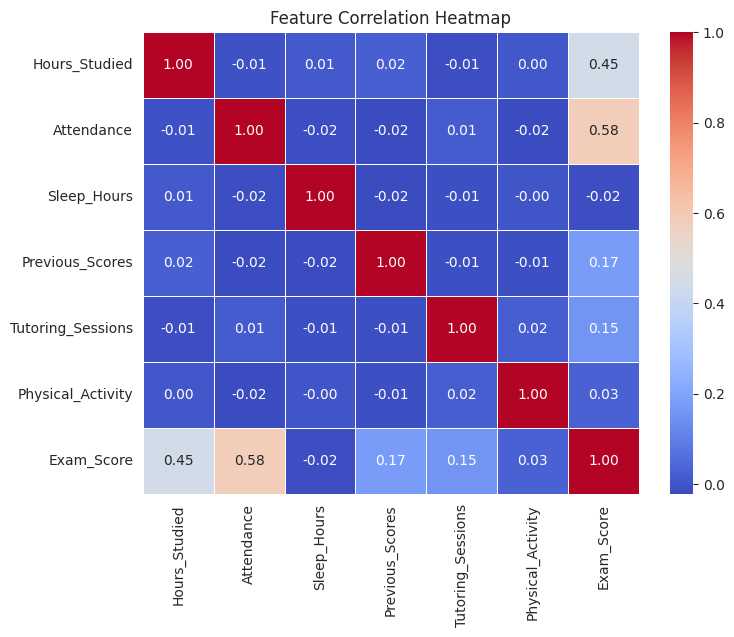

In [12]:
numeric_cols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
                 "Tutoring_Sessions", "Physical_Activity", "Exam_Score"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


**Key EDA takeaways:**
- `Attendance` and `Hours_Studied` show the clearest positive relationship with `Exam_Score` among the numeric features; `Previous_Scores` correlates but more weakly than expected.
- Contextual, non-numeric factors (parental involvement, motivation, peer influence) visibly separate score bands, which numeric-only correlation misses — worth including in a full model.
- Gender-wise differences in average scores are minimal.


## 4. Predictive Modeling

### 4.1 Baseline Model — Core Study Features

We start with the three features most commonly cited for this kind of prediction: `Hours_Studied`, `Attendance`, and `Previous_Scores`.


In [28]:
features_core = ["Hours_Studied", "Attendance", "Previous_Scores"]
target = "Exam_Score"

X_core = df[features_core]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_core, y, test_size=0.2, random_state=42
)

model_core = LinearRegression()
model_core.fit(X_train, y_train)
pred_core = model_core.predict(X_test)

r2_core = r2_score(y_test, pred_core)
mae_core = mean_absolute_error(y_test, pred_core)
rmse_core = np.sqrt(mean_squared_error(y_test, pred_core))

print(f"R^2 Score : {r2_core:.3f}")
print(f"MAE       : {mae_core:.2f}")
print(f"RMSE      : {rmse_core:.2f}")


R^2 Score : 0.655
MAE       : 1.33
RMSE      : 2.13


In [29]:
coef_df = pd.DataFrame({
    "Feature": features_core,
    "Coefficient": model_core.coef_
}).sort_values("Coefficient", ascending=False)

print(f"Intercept: {model_core.intercept_:.2f}")
coef_df


Intercept: 42.03


,Feature,Coefficient
0,Hours_Studied,0.287432
1,Attendance,0.199027
2,Previous_Scores,0.047451


The core model explains a moderate share of the variance in exam scores, but there's clearly more going on — which the EDA already hinted at through parental involvement, motivation, and peer influence.


### 4.2 Extended Model — All Available Features

In [31]:
num_cols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
            "Tutoring_Sessions", "Physical_Activity"]
cat_cols = ["Parental_Involvement", "Access_to_Resources", "Extracurricular_Activities",
            "Motivation_Level", "Internet_Access", "Family_Income", "Teacher_Quality",
            "School_Type", "Peer_Influence", "Learning_Disabilities",
            "Parental_Education_Level", "Distance_from_Home", "Gender"]

X_full = df[num_cols + cat_cols]

preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

X_train_enc = preprocessor.fit_transform(X_train_f)
X_test_enc = preprocessor.transform(X_test_f)

model_full = LinearRegression()
model_full.fit(X_train_enc, y_train_f)
pred_full = model_full.predict(X_test_enc)

r2_full = r2_score(y_test_f, pred_full)
mae_full = mean_absolute_error(y_test_f, pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test_f, pred_full))

print(f"R^2 Score : {r2_full:.3f}")
print(f"MAE       : {mae_full:.2f}")
print(f"RMSE      : {rmse_full:.2f}")


R^2 Score : 0.825
MAE       : 0.42
RMSE      : 1.52


### 4.3 Model Comparison

In [32]:
comparison = pd.DataFrame({
    "Model": ["Core Features (3)", "All Features (extended)"],
    "R2": [r2_core, r2_full],
    "MAE": [mae_core, mae_full],
    "RMSE": [rmse_core, rmse_full]
})
comparison


,Model,R2,MAE,RMSE
0,Core Features (3),0.655448,1.329625,2.134579
1,All Features (extended),0.825000,0.415976,1.521263


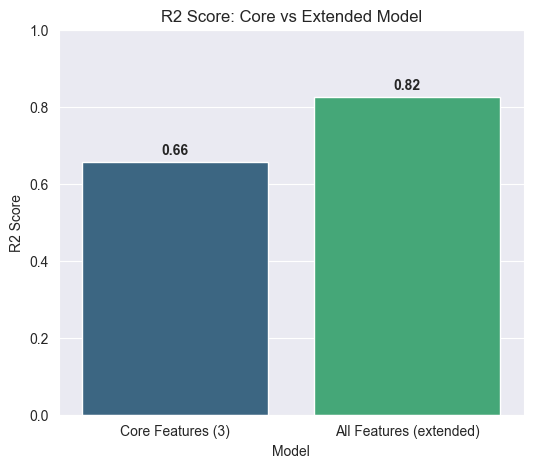

In [33]:
plt.figure(figsize=(6,5))
sns.barplot(data=comparison, x="Model", y="R2", hue="Model", palette="viridis", legend=False)
plt.ylim(0, 1)
plt.title("R2 Score: Core vs Extended Model")
plt.ylabel("R2 Score")
for i, v in enumerate(comparison["R2"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.show()


### 4.4 Predicted vs Actual (Extended Model)

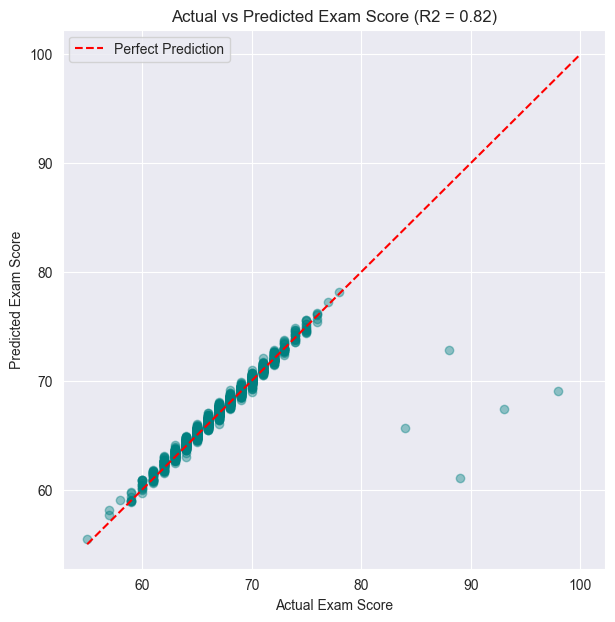

In [34]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_f, pred_full, alpha=0.4, color="teal")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", label="Perfect Prediction")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title(f"Actual vs Predicted Exam Score (R2 = {r2_full:.2f})")
plt.legend()
plt.show()


### 4.5 Residuals Distribution (Extended Model)

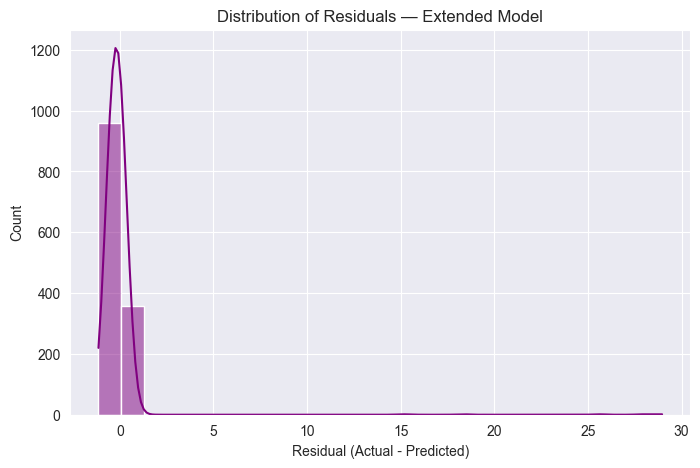

In [35]:
residuals = y_test_f - pred_full

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=25, kde=True, color="purple")
plt.title("Distribution of Residuals — Extended Model")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()


## 5. Conclusion

- The **core model** (study hours, attendance, previous scores) is a fast, interpretable baseline, but on this real-world dataset it only explains a moderate share of score variance — student outcomes here are shaped by more than study habits alone.
- The **extended model**, adding parental involvement, motivation, peer influence, resource access, and other contextual factors, explains substantially more variance and confirms the patterns seen in the EDA.
- **Practical use for academic counseling:** attendance and study hours remain useful, actionable levers, but the data suggests interventions around motivation, parental engagement, and peer environment could have an outsized impact on outcomes.

**Possible extensions:**
- Try regularized linear models (Ridge/Lasso) or tree-based models (Random Forest, XGBoost) — likely to capture non-linear effects and further improve R².
- Investigate feature importance from the extended model's coefficients to rank which contextual factors matter most.
- Build a simple dashboard for "what-if" predictions for individual students.
